# Signal Extraction Demo (summarize_LoCo)

This notebook demonstrates the `spine_extraction` signal extraction pipeline,
which is the Python equivalent of MATLAB's `summarize_LoCo.m`.

It walks through each stage:

1. Load registered data from Zarr (output of notebook 01)
2. Per-trial source localization (temporal filtering, matched filter, DoG, NMS)
3. Cross-trial alignment and valid trial selection
4. Source selection from averaged activity image
5. High-resolution NMF signal extraction
6. Visualize extracted signals
7. Compare with MATLAB results

In [7]:
# Auto-reload all modules so code changes take effect without restarting the kernel
%load_ext autoreload
%autoreload 2

import logging
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(name)s %(levelname)s: %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load registered data

We load the Zarr store produced by the motion correction notebook. This contains
downsampled registered movies and alignment metadata for each trial.

In [8]:
import os

from spine_extraction.io.zarr_store import ExperimentStore
from spine_extraction.config import ExtractionConfig

# Point to the Zarr store from notebook 01
data_dir = Path(os.environ["SPINE_TEST_DATA"]) / "test_scan_00001_20240924_110500"
zarr_path = data_dir / "registered.zarr"
assert zarr_path.exists(), f"Zarr store not found: {zarr_path}\nRun notebook 01 first."

store = ExperimentStore(zarr_path)

# List available trials
import zarr
trials_grp = store.root["trials"]
trial_keys = sorted(trials_grp.keys())
print(f"Available trials: {trial_keys}")

# Configure extraction (matching MATLAB summarize_LoCo defaults for Bergamo)
config = ExtractionConfig(
    microscope="bergamo",
    sigma_px=1.33,
    nmf_iter=2,
    dXY=3,
    denoise_window_s=0.2,
    baseline_window_glu_s=4.0,
    tau_s=0.03,
    max_synapse_density=0.01,
    motion_thresh=2.5,
    nan_thresh=0.33,
    activity_channel=2,
)
print(f"\nExtraction config:")
print(f"  sigma_px={config.sigma_px}, dXY={config.dXY}, sel_radius={config.sel_radius}")
print(f"  tau_s={config.tau_s}, denoise_window_s={config.denoise_window_s}")
print(f"  baseline_window_glu_s={config.baseline_window_glu_s}")
print(f"  nmf_iter={config.nmf_iter}, max_synapse_density={config.max_synapse_density}")

2026-03-10 13:16:20 spine_extraction.io.zarr_store INFO: Opened Zarr store at C:\Users\user\Desktop\iGluSnFR test data\750098\2024-09-24\test_scan_00001_20240924_110500\registered.zarr


Available trials: ['trial_001']

Extraction config:
  sigma_px=1.33, dXY=3, sel_radius=6
  tau_s=0.03, denoise_window_s=0.2
  baseline_window_glu_s=4.0
  nmf_iter=2, max_synapse_density=0.01


In [9]:
# Load alignment data and registered movie for each trial
trial_indices = [int(k.split("_")[-1]) for k in trial_keys]
n_trials = len(trial_indices)

alignment_data = []
movies_ds = []       # downsampled movies (for mean images, visualization)
mean_images = []

# Check if full-resolution data is available
full_res_available = False
for trial_idx in trial_indices:
    adata = store.load_alignment_data(trial_idx)
    alignment_data.append(adata)

    # Always load DS for mean images (lightweight)
    reg_ds = store.load_registered_ds(trial_idx)
    n_ch = adata.num_channels
    n_ds_frames = reg_ds.shape[2] // n_ch
    movie_4d = reg_ds.reshape(
        reg_ds.shape[0], reg_ds.shape[1], n_ds_frames, n_ch
    ).transpose(0, 1, 3, 2)  # -> (H, W, C, T)
    movies_ds.append(movie_4d)

    mean_im = np.nanmean(movie_4d, axis=3)
    mean_images.append(mean_im)

    # Check for full-res data
    try:
        trial_grp = store.root[f"trials/trial_{trial_idx:03d}"]
        if "registered_raw" in trial_grp:
            full_res_available = True
    except KeyError:
        pass

    print(f"Trial {trial_idx}: DS movie shape {movie_4d.shape}, "
          f"{n_ch} channels, {n_ds_frames} ds frames, "
          f"align_hz={adata.align_hz:.1f}")

h, w = movies_ds[0].shape[:2]
n_ch = movies_ds[0].shape[2]
# Keep `movies` as alias for backward compatibility with visualization cells
movies = movies_ds

# Determine analysis framerate
if full_res_available:
    full_res_hz = 1.0 / alignment_data[0].frame_time
    print(f"\nFull-resolution data available: {full_res_hz:.1f} Hz")
    print(f"  tau_s={config.tau_s}s -> {config.tau_s * full_res_hz:.1f} frames (matched filter)")
else:
    full_res_hz = alignment_data[0].align_hz
    print(f"\nFull-resolution data NOT available (run notebook 01 with save_full_resolution=True)")
    print(f"  Using downsampled: {full_res_hz:.1f} Hz, tau = {config.tau_s * full_res_hz:.1f} frames")

print(f"\nImage size: {h} x {w}, {n_ch} channels, {n_trials} trials")

Trial 1: DS movie shape (70, 149, 2, 21066), 2 channels, 21066 ds frames, align_hz=53.7

Full-resolution data available: 429.9 Hz
  tau_s=0.03s -> 12.9 frames (matched filter)

Image size: 70 x 149, 2 channels, 1 trials


C:\Users\user\AppData\Local\Temp\ipykernel_14812\4084782553.py:24: RuntimeWarning: Mean of empty slice
  mean_im = np.nanmean(movie_4d, axis=3)


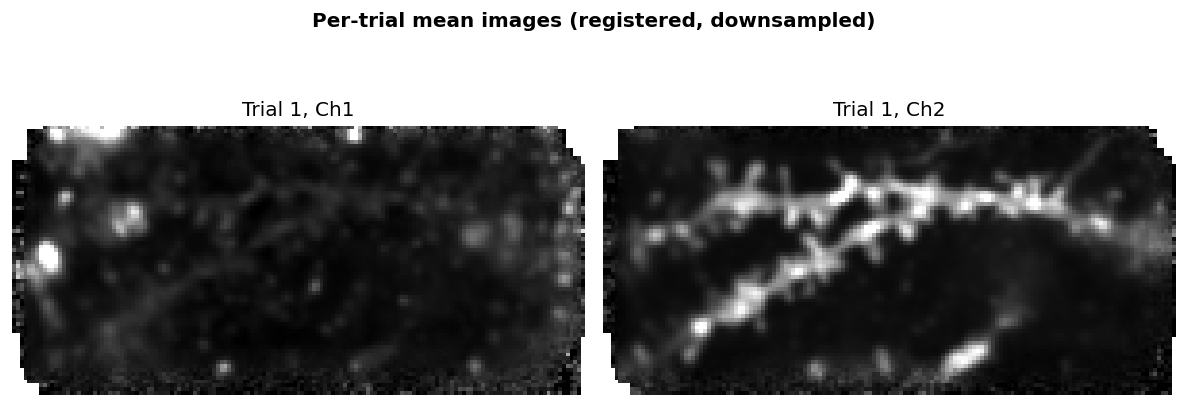

In [10]:
# Show mean images per trial
fig, axes = plt.subplots(n_trials, n_ch, figsize=(5 * n_ch, 4 * n_trials), squeeze=False)
for t_ix, (trial_idx, mean_im) in enumerate(zip(trial_indices, mean_images)):
    for ch in range(n_ch):
        im = mean_im[:, :, ch]
        axes[t_ix, ch].imshow(
            im, cmap="gray",
            vmin=np.nanpercentile(im, 1), vmax=np.nanpercentile(im, 99.5),
        )
        axes[t_ix, ch].set_title(f"Trial {trial_idx}, Ch{ch+1}")
        axes[t_ix, ch].axis("off")
fig.suptitle("Per-trial mean images (registered, downsampled)", fontweight="bold")
plt.tight_layout()

## 2. Per-trial source localization

For each trial, we:
- Extract the activity channel (glutamate)
- Temporal smoothing + baseline subtraction + MAD noise normalization
- Exponential matched filter (backward causal)
- Difference of Gaussians spatial filter
- Spatiotemporal non-maximum suppression to build an activity image

This ports `localizeSources_vIM.m`.

In [11]:
%%time
from spine_extraction.extraction.localize import localize_sources
import warnings

act_ch = config.activity_channel - 1

def _load_activity_channel(trial_idx, adata):
    """Load activity channel movie, preferring full-res if available."""
    n_ch = adata.num_channels
    if full_res_available:
        reg_data = store.load_registered_raw(trial_idx)
        hz = 1.0 / adata.frame_time
    else:
        reg_data = store.load_registered_ds(trial_idx)
        hz = adata.align_hz
    n_frames = reg_data.shape[2] // n_ch
    movie_4d = reg_data.reshape(
        reg_data.shape[0], reg_data.shape[1], n_frames, n_ch
    ).transpose(0, 1, 3, 2)  # -> (H, W, C, T)
    movie_act = movie_4d[:, :, act_ch, :]
    del reg_data, movie_4d  # free memory
    return movie_act, hz

activity_images = [None] * n_trials
all_peaks = [None] * n_trials
keep_trials = np.ones(n_trials, dtype=bool)

# Localization uses downsampled data — it only finds spatial peak locations,
# so 54 Hz is adequate. Full-res (168k frames) would OOM at ~13 GiB/array.
# Full-res is used later for NMF extraction where temporal resolution matters.
for t_ix, (trial_idx, adata) in enumerate(zip(trial_indices, alignment_data)):
    try:
        movie_act = movies_ds[t_ix][:, :, act_ch, :]
        hz = adata.align_hz
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            act_img, peaks = localize_sources(movie_act, config, hz)
        activity_images[t_ix] = act_img
        all_peaks[t_ix] = peaks
        print(f"Trial {trial_idx}: {len(peaks.row)} peaks detected "
              f"(Ch{config.activity_channel}, {movie_act.shape[0]}x{movie_act.shape[1]}, "
              f"{movie_act.shape[2]} frames @ {hz:.1f} Hz)")
    except Exception as e:
        print(f"Trial {trial_idx}: FAILED - {e}")
        import traceback; traceback.print_exc()
        keep_trials[t_ix] = False

2026-03-10 13:18:14 spine_extraction.extraction.localize INFO: Localized 36 sources


Trial 1: 36 peaks detected (Ch2, 70x149, 21066 frames @ 53.7 Hz)
CPU times: total: 7min 1s
Wall time: 1min 48s


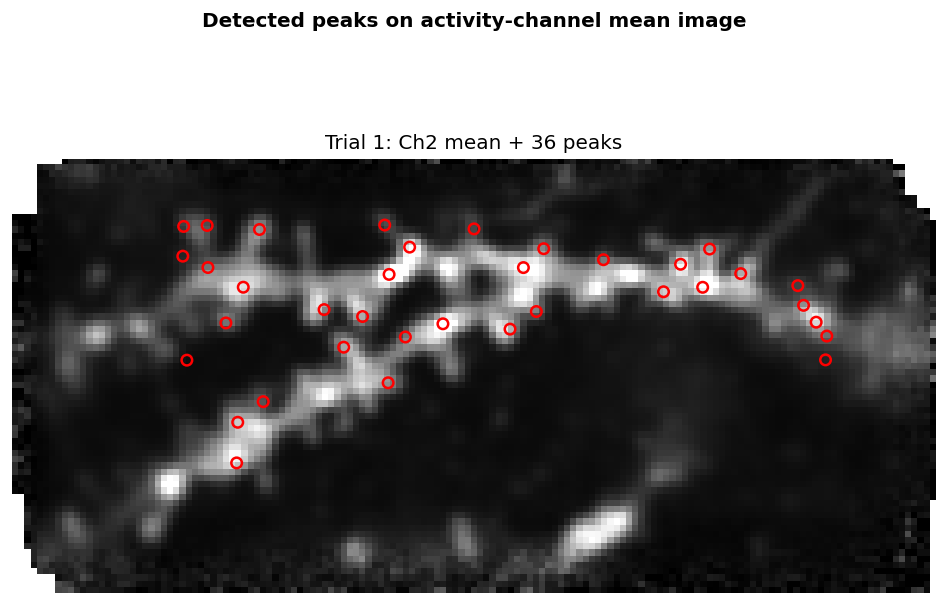

In [12]:
# Visualize detected peaks overlaid on mean activity-channel image
valid_indices = np.where(keep_trials)[0]
n_valid = len(valid_indices)

fig, axes = plt.subplots(1, max(1, n_valid), figsize=(8 * n_valid, 6), squeeze=False)
for i, t_ix in enumerate(valid_indices):
    ax = axes[0, i]
    peaks = all_peaks[t_ix]

    # Time-average of the activity channel as background
    mean_act_ch = mean_images[t_ix][:, :, act_ch]
    vmin = np.nanpercentile(mean_act_ch, 1)
    vmax = np.nanpercentile(mean_act_ch, 99.5)
    ax.imshow(mean_act_ch, cmap="gray", vmin=vmin, vmax=vmax)

    if len(peaks.row) > 0:
        ax.scatter(
            peaks.col, peaks.row, s=40,
            facecolors="none", edgecolors="r", linewidths=1.5,
        )
    ax.set_title(f"Trial {trial_indices[t_ix]}: Ch{config.activity_channel} mean + {len(peaks.row)} peaks")
    ax.axis("off")

fig.suptitle("Detected peaks on activity-channel mean image", fontweight="bold")
plt.tight_layout()

## 3. Cross-trial alignment

Align all trials to a common template and identify valid trials based on
cross-correlation. This ports `summarize_LoCo.m` lines 162-210:

- Build template from best-correlated subset of trials
- Pad images with NaN to template size
- Align each trial via `xcorr2_nans` (coarse + fine)
- Threshold on correlation and valid pixel fraction

In [13]:
%%time
from spine_extraction.extraction.cross_trial_align import align_trials_cross

# Stack images into arrays
mean_stack = np.full((h, w, n_ch, n_trials), np.nan, dtype=np.float32)
act_stack = np.full((h, w, n_trials), np.nan, dtype=np.float32)

for i in valid_indices:
    mean_stack[:, :, :, i] = mean_images[i]
    act_stack[:, :, i] = activity_images[i]

cross_result = align_trials_cross(mean_stack, act_stack, config, keep_trials)

print(f"Template shape: {cross_result.template.shape}")
print(f"Valid trials: {cross_result.valid_trials} ({len(cross_result.valid_trials)}/{n_trials})")
print(f"Correlation coefficients: {cross_result.corr_coeffs}")
print(f"Motion offsets (row, col):\n{cross_result.motion}")

2026-03-10 13:18:19 spine_extraction.registration.template INFO: Building cross-trial template from 1 trials
2026-03-10 13:18:19 spine_extraction.registration.template INFO: Best reference trial: 0 (median corr 1.0000, 1 aligned trials)
C:\Users\user\Documents\Git\spine_extraction\src\spine_extraction\registration\template.py:222: RuntimeWarning: Mean of empty slice
  template = np.nanmean(aligned, axis=2)
2026-03-10 13:18:19 spine_extraction.extraction.cross_trial_align INFO: Cross-trial alignment: 1/1 trials valid (corr_thresh=0.9000)


Template shape: (80, 159)
Valid trials: [0] (1/1)
Correlation coefficients: [1.]
Motion offsets (row, col):
[[-0.00024335]
 [ 0.00457925]]
CPU times: total: 2 s
Wall time: 5.7 s


C:\Users\user\AppData\Local\Temp\ipykernel_14812\533749574.py:12: RuntimeWarning: Mean of empty slice
  avg_mean_act = np.nanmean(
C:\Users\user\AppData\Local\Temp\ipykernel_14812\533749574.py:22: RuntimeWarning: Mean of empty slice
  avg_act = np.nanmean(


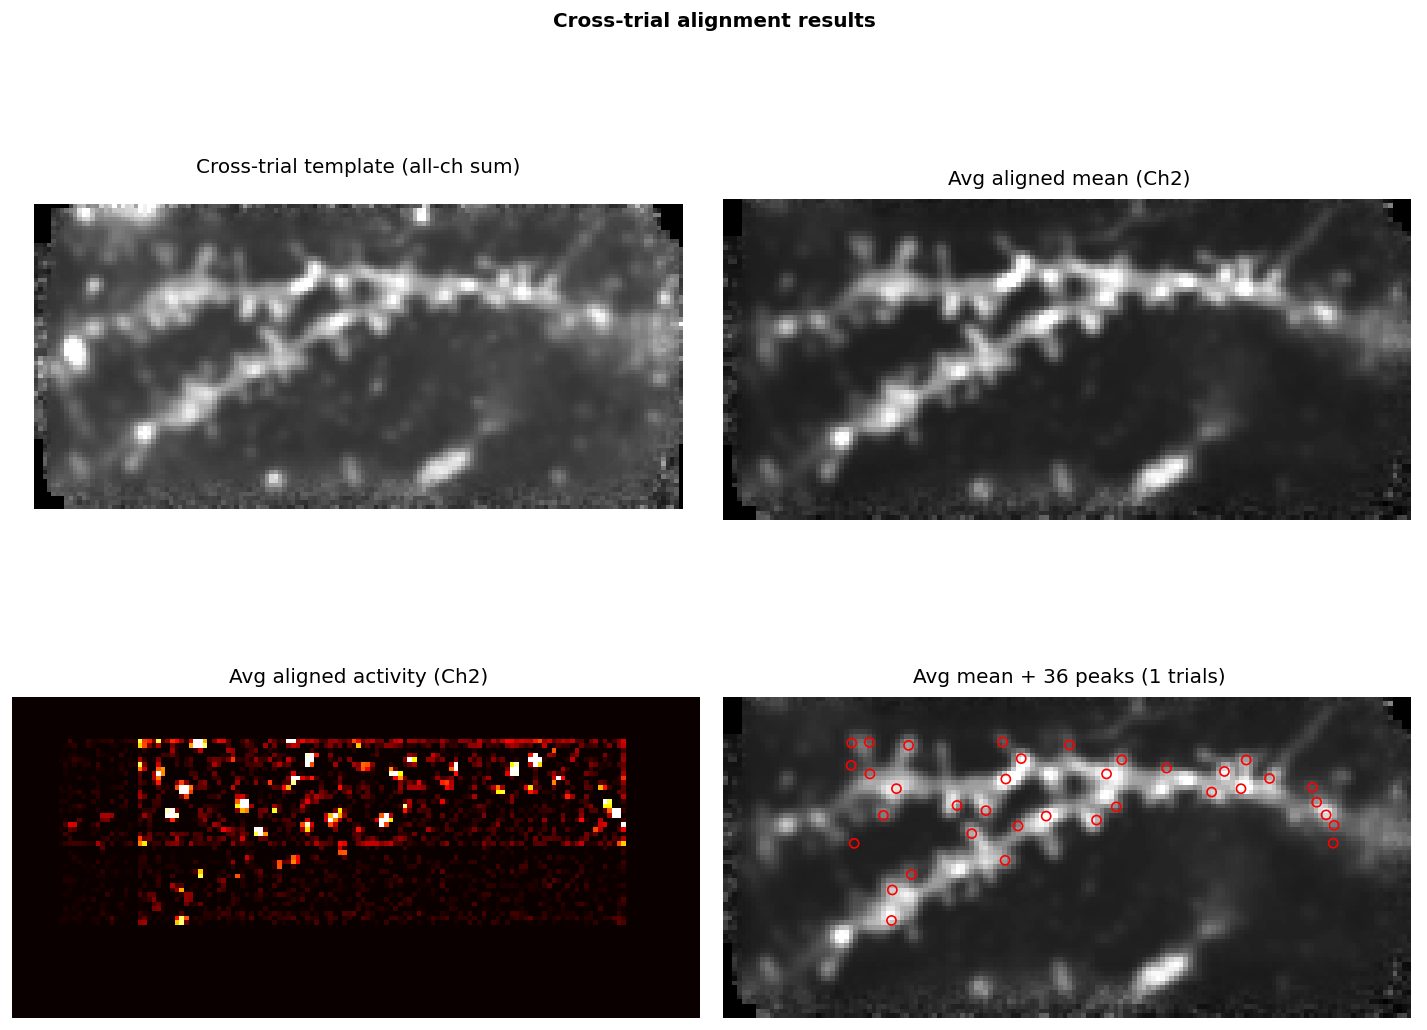

In [14]:
# Visualize template and aligned images
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Template (sum of all channels, used for alignment)
tmpl = cross_result.template
axes[0, 0].imshow(tmpl, cmap="gray",
                  vmin=np.nanpercentile(tmpl, 1), vmax=np.nanpercentile(tmpl, 99.5))
axes[0, 0].set_title("Cross-trial template (all-ch sum)")
axes[0, 0].axis("off")

# Average of aligned mean images for the activity channel
avg_mean_act = np.nanmean(
    cross_result.aligned_mean[:, :, act_ch, cross_result.valid_trials], axis=2
)
axes[0, 1].imshow(avg_mean_act, cmap="gray",
                  vmin=np.nanpercentile(avg_mean_act, 1),
                  vmax=np.nanpercentile(avg_mean_act, 99.5))
axes[0, 1].set_title(f"Avg aligned mean (Ch{config.activity_channel})")
axes[0, 1].axis("off")

# Average activity image
avg_act = np.nanmean(
    cross_result.aligned_activity[:, :, cross_result.valid_trials], axis=2
)
vmax = np.nanpercentile(avg_act, 99.5) if np.any(~np.isnan(avg_act)) else 1
axes[1, 0].imshow(avg_act, cmap="hot", vmin=0, vmax=vmax)
axes[1, 0].set_title(f"Avg aligned activity (Ch{config.activity_channel})")
axes[1, 0].axis("off")

# Average mean image + per-trial peaks overlaid
axes[1, 1].imshow(avg_mean_act, cmap="gray",
                  vmin=np.nanpercentile(avg_mean_act, 1),
                  vmax=np.nanpercentile(avg_mean_act, 99.5))
n_total_peaks = 0
for t_ix in cross_result.valid_trials:
    peaks = all_peaks[t_ix]
    if peaks is not None and len(peaks.row) > 0:
        axes[1, 1].scatter(peaks.col, peaks.row, s=30,
                           facecolors="none", edgecolors="r", linewidths=1)
        n_total_peaks += len(peaks.row)
axes[1, 1].set_title(f"Avg mean + {n_total_peaks} peaks ({len(cross_result.valid_trials)} trials)")
axes[1, 1].axis("off")

fig.suptitle("Cross-trial alignment results", fontweight="bold")
plt.tight_layout()

In [15]:
# Plot correlation coefficients for each trial
if n_trials > 1:
    fig, ax = plt.subplots(figsize=(10, 3))
    colors = ["green" if i in cross_result.valid_trials else "red" for i in range(n_trials)]
    ax.bar(range(n_trials), cross_result.corr_coeffs, color=colors, edgecolor="k", linewidth=0.5)
    ax.set_xlabel("Trial index")
    ax.set_ylabel("Correlation with template")
    ax.set_title("Cross-trial correlation (green=valid, red=rejected)")
    ax.axhline(y=config.valid_trial_corr_min, color="orange", linestyle="--", label=f"min corr={config.valid_trial_corr_min}")
    ax.legend()
    plt.tight_layout()
else:
    print(f"Single trial — skipping cross-trial correlation plot (corr={cross_result.corr_coeffs[0]:.4f})")

Single trial — skipping cross-trial correlation plot (corr=1.0000)


## 4. Source selection

Select synaptic sources from the cross-trial averaged activity image.
This ports `summarize_LoCo.m` lines 220-275:

- Average activity images across valid trials
- Subtract local median baseline
- Find local maxima with iterative NMS
- Apply density threshold
- Dilate pixels around each source center

In [16]:
from spine_extraction.extraction.source_selection import select_sources

# Valid pixel mask: pixels imaged in enough of the valid trials
valid_pix = np.mean(
    ~np.isnan(cross_result.aligned_mean[:, :, 0, cross_result.valid_trials]),
    axis=2,
) > (1 - config.nan_thresh)

sources = select_sources(
    cross_result.aligned_activity,
    cross_result.valid_trials,
    config,
    valid_pixel_mask=valid_pix,
)

print(f"Sources found: {sources.n_sources}")
print(f"Source rows: {sources.rows[:10]}{'...' if sources.n_sources > 10 else ''}")
print(f"Source cols: {sources.cols[:10]}{'...' if sources.n_sources > 10 else ''}")
print(f"sel_pix shape: {sources.sel_pix.shape}")
print(f"Pixels per source (median): {np.median(np.sum(sources.sel_pix, axis=(0, 1))):.0f}")

2026-03-10 13:18:20 spine_extraction.extraction.source_selection INFO: Selected 44 sources above density threshold
2026-03-10 13:18:20 spine_extraction.extraction.source_selection INFO: After pruning: 44 sources with >= 5 pixels each


Sources found: 44
Source rows: [14 20 26 27 11 26 16 30 14 24]...
Source cols: [112  37  34  80  39 129 107  53  64  50]...
sel_pix shape: (70, 149, 44)
Pixels per source (median): 113


C:\Users\user\AppData\Local\Temp\ipykernel_14812\2017934139.py:5: RuntimeWarning: Mean of empty slice
  avg_mean_act = np.nanmean(


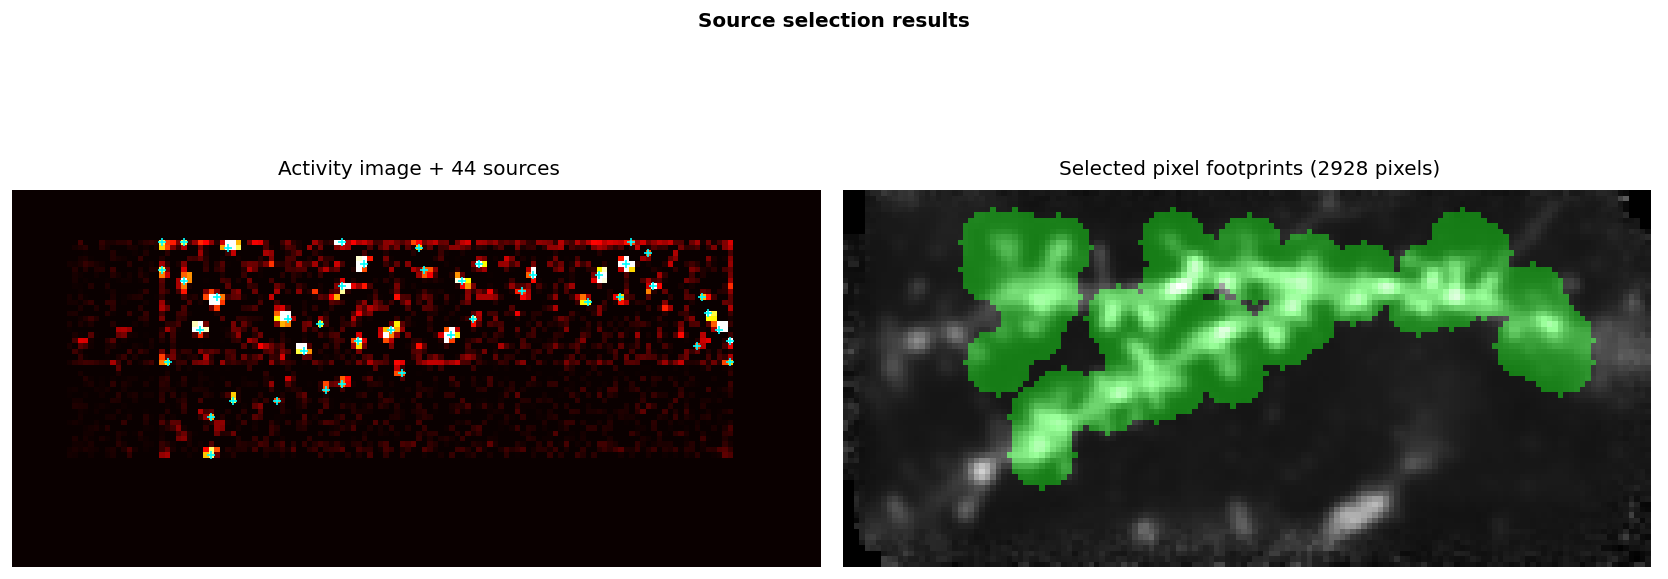

In [17]:
# Visualize sources on the averaged activity image
avg_act = np.mean(
    cross_result.aligned_activity[:, :, cross_result.valid_trials], axis=2
)
avg_mean_act = np.nanmean(
    cross_result.aligned_mean[:, :, act_ch, cross_result.valid_trials], axis=2
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Activity image with source locations
vmax = np.nanpercentile(avg_act, 99.5) if np.any(~np.isnan(avg_act)) else 1
axes[0].imshow(avg_act, cmap="hot", vmin=0, vmax=vmax)
if sources.n_sources > 0:
    axes[0].scatter(sources.cols, sources.rows, s=20, c="cyan", marker="+", linewidths=1)
axes[0].set_title(f"Activity image + {sources.n_sources} sources")
axes[0].axis("off")

# Union of selected pixels on activity-channel mean
sel_union = np.any(sources.sel_pix, axis=2) if sources.n_sources > 0 else np.zeros((h, w), dtype=bool)
overlay = avg_mean_act.copy()
overlay_rgb = np.stack([overlay] * 3, axis=-1)
overlay_rgb = (overlay_rgb - np.nanmin(overlay_rgb)) / (np.nanmax(overlay_rgb) - np.nanmin(overlay_rgb) + 1e-10)
overlay_rgb[sel_union, 1] = np.clip(overlay_rgb[sel_union, 1] + 0.4, 0, 1)
axes[1].imshow(overlay_rgb)
axes[1].set_title(f"Selected pixel footprints ({np.sum(sel_union)} pixels)")
axes[1].axis("off")

fig.suptitle("Source selection results", fontweight="bold")
plt.tight_layout()

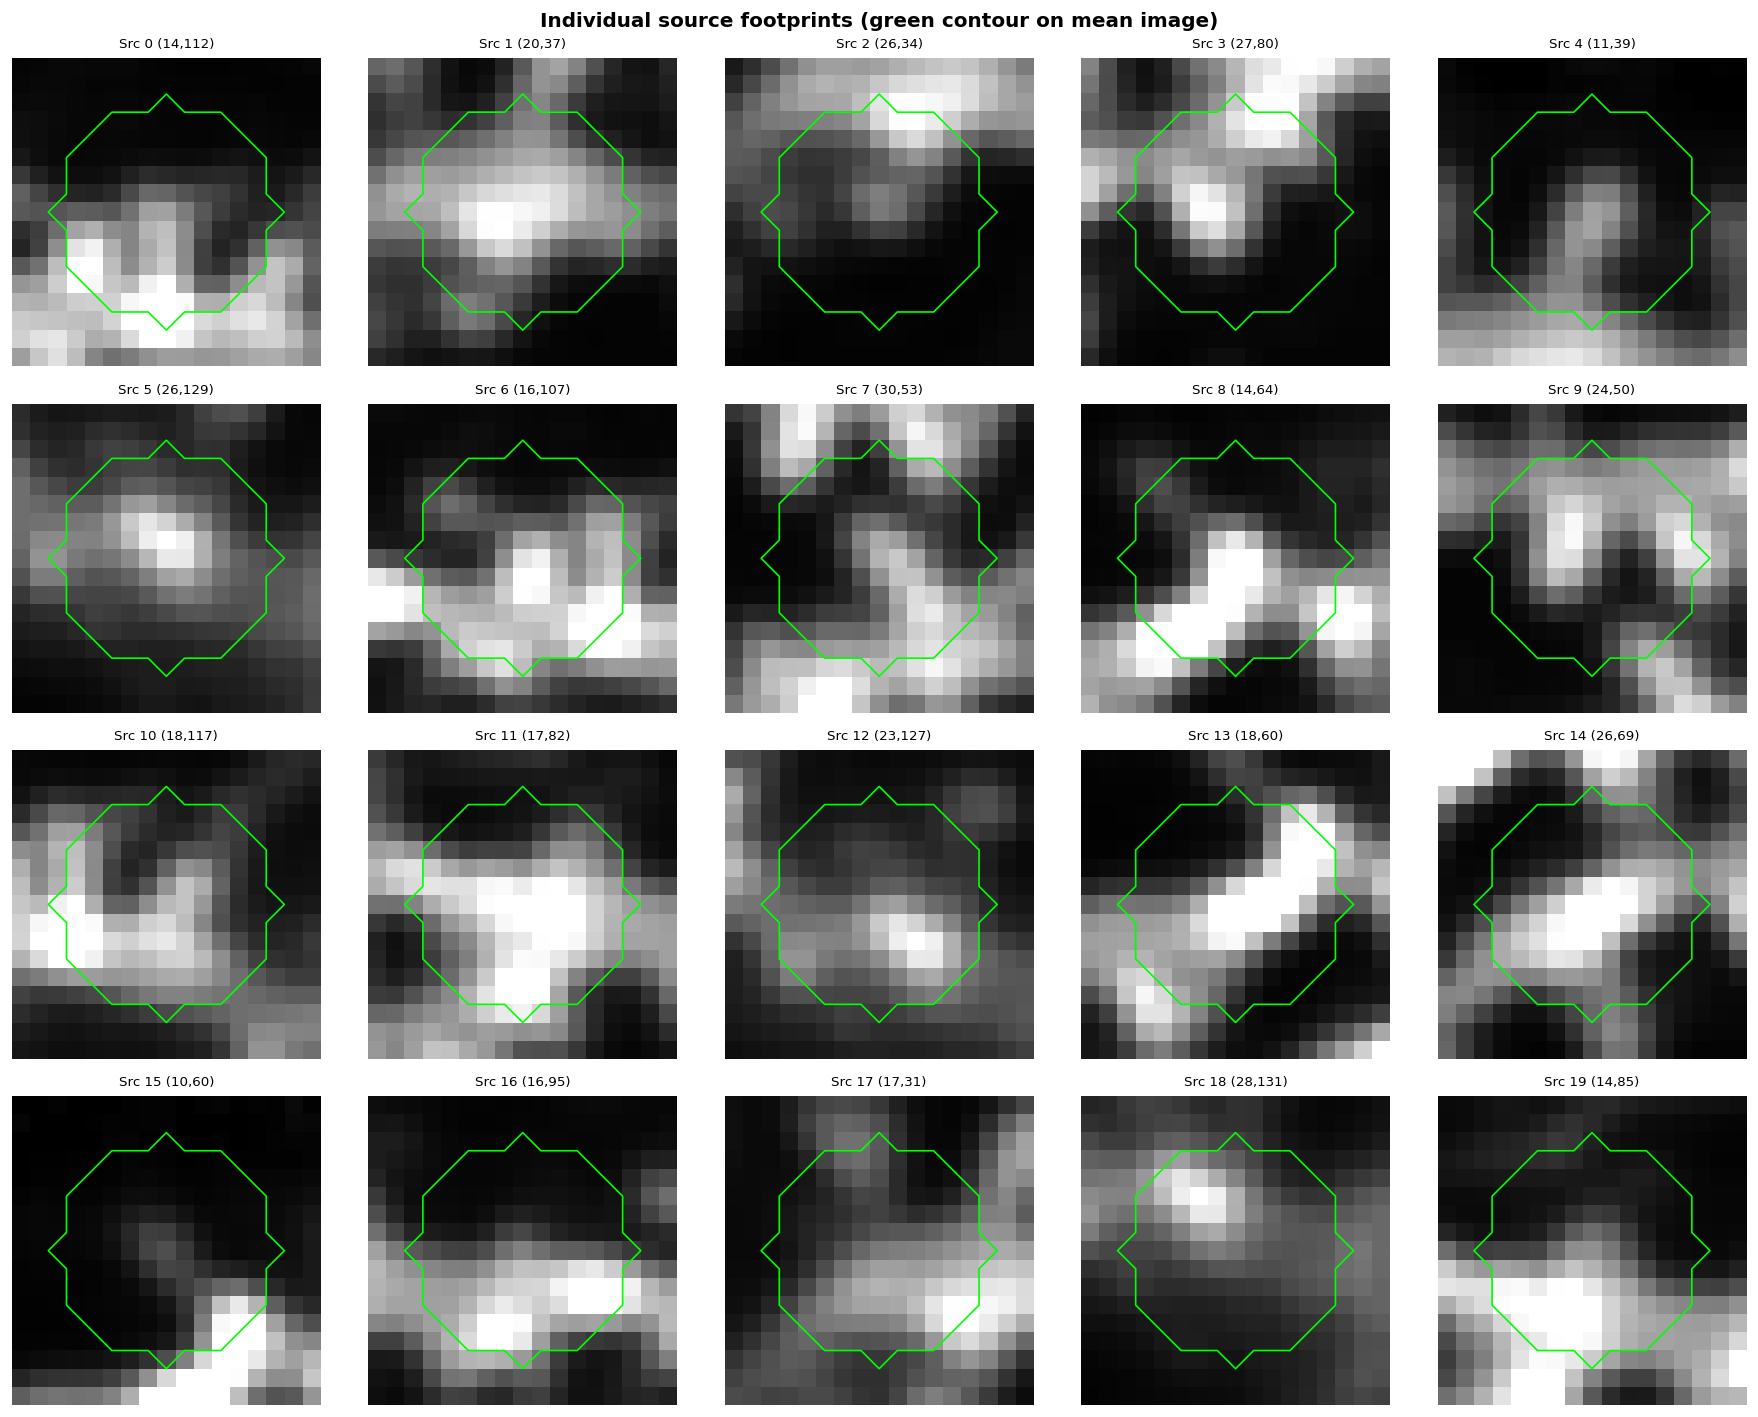

In [18]:
# Show individual source footprints (first 20)
n_show = min(20, sources.n_sources)
if n_show > 0:
    cols_plot = min(5, n_show)
    rows_plot = (n_show + cols_plot - 1) // cols_plot
    fig, axes = plt.subplots(rows_plot, cols_plot, figsize=(3 * cols_plot, 3 * rows_plot))
    axes_flat = np.array(axes).ravel()

    for i in range(n_show):
        r, c = int(round(sources.rows[i])), int(round(sources.cols[i]))
        # Crop a region around the source
        pad = config.sel_radius + 2
        r0, r1 = max(0, r - pad), min(h, r + pad + 1)
        c0, c1 = max(0, c - pad), min(w, c + pad + 1)

        footprint = sources.sel_pix[r0:r1, c0:c1, i]
        bg = avg_mean_act[r0:r1, c0:c1]

        axes_flat[i].imshow(bg, cmap="gray",
                            vmin=np.nanpercentile(avg_mean_act, 5),
                            vmax=np.nanpercentile(avg_mean_act, 99))
        axes_flat[i].contour(footprint.astype(float), levels=[0.5], colors="lime", linewidths=1)
        axes_flat[i].set_title(f"Src {i} ({r},{c})", fontsize=8)
        axes_flat[i].axis("off")

    for i in range(n_show, len(axes_flat)):
        axes_flat[i].axis("off")

    fig.suptitle("Individual source footprints (green contour on mean image)", fontweight="bold")
    plt.tight_layout()
else:
    print("No sources to display.")

## 5. Motion frame detection

Detect motion-corrupted frames to censor during extraction.
This ports `loadAndProcessTrialAsync.m` lines 26-31:

- Median filter the reconstruction error trace
- Detect large deviations with hysteresis thresholding
- Morphological dilation + closing to extend censoring window
- Discard initial frames

In [19]:
from spine_extraction.pipeline.runner import _detect_motion_frames

discard_masks = []
for t_ix, adata in enumerate(alignment_data):
    discard = _detect_motion_frames(adata, config)
    discard_masks.append(discard)
    n_discard = np.sum(discard)
    pct = 100 * n_discard / len(discard) if len(discard) > 0 else 0
    print(f"Trial {trial_indices[t_ix]}: {n_discard}/{len(discard)} frames discarded ({pct:.1f}%)")

Trial 1: 36/21066 frames discarded (0.2%)


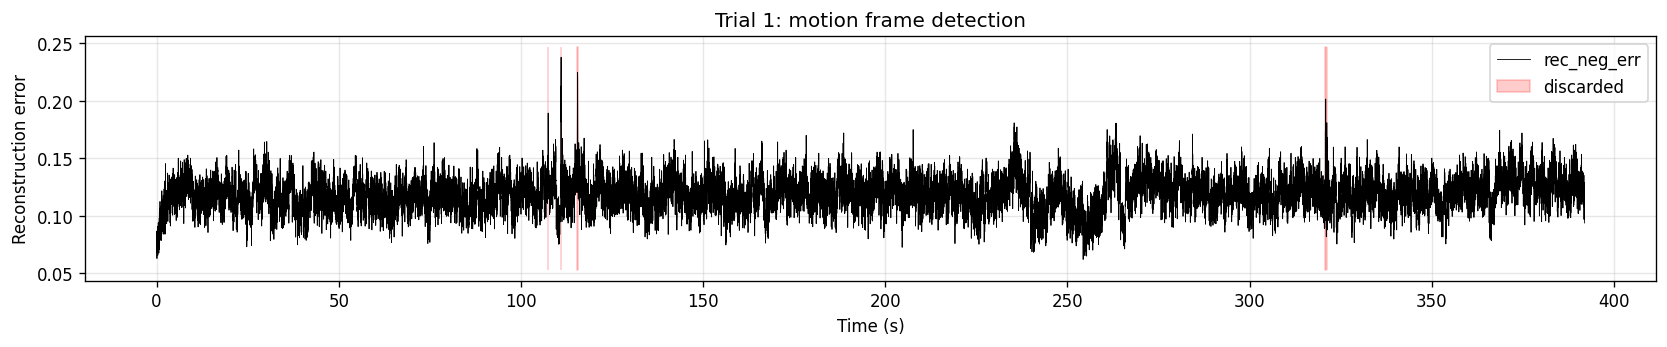

In [20]:
# Plot reconstruction error with discarded frames highlighted
for t_ix in range(n_trials):
    adata = alignment_data[t_ix]
    discard = discard_masks[t_ix]
    t = np.arange(len(adata.rec_neg_err)) / adata.align_hz

    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(t, adata.rec_neg_err, "k-", lw=0.5, label="rec_neg_err")
    if np.any(discard):
        ax.fill_between(t, ax.get_ylim()[0], ax.get_ylim()[1],
                        where=discard, color="red", alpha=0.2, label="discarded")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Reconstruction error")
    ax.set_title(f"Trial {trial_indices[t_ix]}: motion frame detection")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

## 6. High-resolution NMF signal extraction

For each valid trial, extract signals via constrained NMF.
This ports `extractTrial.m` / `processAllTrials_Async.m`:

- Decompose into independent spatial subproblems (connected components)
- For each subproblem, alternating optimization of:
  - **S** (temporal signals) via L-BFGS with non-negativity
  - **B** (baseline) via per-pixel bounded least squares
  - **Hs** (spatial footprints) via L-BFGS with PSF convolution prior

**Important**: This step uses full-resolution registered data when available
(`save_full_resolution=True` in notebook 01). With tau_s=0.03s the indicator
decay is ~13 frames at 430 Hz but only ~1.6 frames at the downsampled 54 Hz,
making temporal deconvolution useless at low rate. Memory is manageable here
because NMF operates on small subproblems (~200 pixels), not the full image.

In [21]:
from spine_extraction.extraction.extract_trial import extract_trial
from spine_extraction.extraction.assemble import compute_denoised, censor_frames

if sources.n_sources == 0:
    print("No sources found - skipping extraction.")
else:
    sel_pix_union = np.any(sources.sel_pix, axis=2)
    print(f"\n{sources.n_sources} sources, {np.sum(sel_pix_union)} selected pixels")


44 sources, 2928 selected pixels


In [22]:
%%time
extraction_results = {}

if sources.n_sources > 0:
    for trial_ix in cross_result.valid_trials:
        trial_idx = trial_indices[trial_ix]
        adata = alignment_data[trial_ix]
        print(f"\n--- Extracting trial {trial_idx} ---")

        # Load activity channel (full-res if available)
        movie_act, analyze_hz = _load_activity_channel(trial_idx, adata)
        n_frames = movie_act.shape[2]
        res_label = "full-res" if full_res_available else "downsampled"
        print(f"  Using {res_label} data: {movie_act.shape}, {analyze_hz:.1f} Hz")

        # Extract selected pixels
        Y_sel = movie_act[sel_pix_union, :].copy()
        Finv = np.ones_like(Y_sel)  # Uniform for Bergamo
        del movie_act  # free memory

        # Censor motion frames
        discard = discard_masks[trial_ix]
        if len(discard) != n_frames:
            # Upsample discard mask from DS rate to full-res rate
            discard_full = np.zeros(n_frames, dtype=bool)
            ds_to_full = np.round(np.linspace(0, n_frames - 1, len(discard))).astype(int)
            for d_ix, full_ix in enumerate(ds_to_full):
                if discard[d_ix]:
                    discard_full[full_ix] = True
        else:
            discard_full = discard[:n_frames]
        Y_sel[:, discard_full] = np.nan
        print(f"  {n_frames} frames, {np.sum(~discard_full)} valid, tau={config.tau_s * analyze_hz:.1f} frames")

        # Run NMF extraction
        try:
            result = extract_trial(
                Y_sel, Finv,
                sources.rows, sources.cols,
                sel_pix_union,
                config, analyze_hz,
            )

            # Post-process: denoised signals and censoring
            denoised = compute_denoised(result.S, config.tau_s, analyze_hz)
            events = censor_frames(result.S, discard_full)
            denoised = censor_frames(denoised, discard_full)

            extraction_results[trial_idx] = {
                "result": result,
                "events": events,
                "denoised": denoised,
                "discard": discard_full,
                "analyze_hz": analyze_hz,
            }
            valid_snr = result.SNR[~np.isnan(result.SNR)]
            if len(valid_snr) > 0:
                print(f"  Done: SNR range [{np.min(valid_snr):.2f}, {np.max(valid_snr):.2f}]")
            else:
                print(f"  Done: all {len(result.SNR)} SNR values are NaN")

        except Exception as e:
            print(f"  FAILED: {e}")
            import traceback; traceback.print_exc()

print(f"\nExtraction complete: {len(extraction_results)}/{len(cross_result.valid_trials)} trials")


--- Extracting trial 1 ---
  Using full-res data: (70, 149, 168528), 429.9 Hz


2026-03-10 13:18:47 spine_extraction.extraction.extract_trial INFO: Decomposed into 18 independent subproblems (19.4 GB available)


  168528 frames, 168492 valid, tau=12.9 frames


2026-03-10 13:18:48 spine_extraction.extraction.extract_trial INFO: Scheduling: max_concurrent=5 (est 1.8 GB/subproblem peak, 19.4 GB available, 4 FFT workers each)
2026-03-10 13:18:48 spine_extraction._utils.torch_helpers INFO: Using CUDA device: NVIDIA GeForce RTX 5080 (14.5 / 15.9 GB VRAM free)
2026-03-10 13:18:48 spine_extraction.extraction.extract_trial INFO: Subproblem 1/18 (id=1): 4 sources, 102 pixels, crop 14x11 — est 0.7 GB, avail 17.5 GB
2026-03-10 13:18:48 spine_extraction.extraction.extract_trial INFO: Subproblem 2/18 (id=2): 3 sources, 85 pixels, crop 15x11 — est 0.6 GB, avail 17.5 GB
2026-03-10 13:18:48 spine_extraction.extraction.extract_trial INFO: Subproblem 3/18 (id=3): 7 sources, 181 pixels, crop 18x19 — est 1.2 GB, avail 17.4 GB
2026-03-10 13:18:48 spine_extraction.extraction.extract_trial INFO: Subproblem 4/18 (id=4): 1 sources, 29 pixels, crop 7x7 — est 0.2 GB, avail 17.4 GB
2026-03-10 13:18:48 spine_extraction.extraction.extract_trial INFO: Subproblem 5/18 (id=5

  Done: SNR range [0.00, 852.38]

Extraction complete: 1/1 trials
CPU times: total: 20min 32s
Wall time: 1min 43s


## Save extraction results to Zarr

Save the extraction outputs back into `registered.zarr` so the interactive
viewer (notebook 03) can load them without re-running extraction.

In [23]:
import zarr

root = zarr.open(str(zarr_path), mode="a")  # append mode

def _save_array(group, name, data):
    """Save array to zarr group, replacing if exists."""
    if name in group:
        del group[name]
    group.create_array(name, data=data)

# --- Summary group: mean image, source locations, sel_pix ---
summ = root.require_group("summary")

# Mean image (H, W, C) — average across valid trials
avg_mean = np.nanmean(
    cross_result.aligned_mean[:, :, :, cross_result.valid_trials], axis=3
).astype(np.float32)
_save_array(summ, "mean_image", avg_mean)

# Source locations, union sel_pix, and per-source initial footprints
src_grp = summ.require_group("sources")
_save_array(src_grp, "locations_r", sources.rows.astype(np.float64))
_save_array(src_grp, "locations_c", sources.cols.astype(np.float64))
_save_array(src_grp, "sel_pix", sel_pix_union.astype(np.uint8))
_save_array(src_grp, "initial_footprints", sources.sel_pix.astype(np.uint8))

# --- Per-trial extraction results ---
for trial_idx, ext in extraction_results.items():
    trial_key = f"trial_{trial_idx:03d}"
    trial_grp = root.require_group(f"trials/{trial_key}")
    ext_grp = trial_grp.require_group("extraction")

    result = ext["result"]
    for name, arr in [
        ("footprints", result.H.astype(np.float32)),
        ("events", ext["events"].astype(np.float32)),
        ("denoised", ext["denoised"].astype(np.float32)),
        ("ls", result.LS.astype(np.float32)),
        ("F0", result.F0.astype(np.float32)),
        ("SNR", result.SNR.astype(np.float32)),
        ("discard_frames", ext["discard"].astype(np.uint8)),
    ]:
        _save_array(ext_grp, name, arr)

    print(f"Trial {trial_idx}: saved {result.H.shape[1]} sources, "
          f"{ext['events'].shape[1]} frames to {trial_key}/extraction/")

print(f"\nSaved to {zarr_path}")

Trial 1: saved 44 sources, 168528 frames to trial_001/extraction/

Saved to C:\Users\user\Desktop\iGluSnFR test data\750098\2024-09-24\test_scan_00001_20240924_110500\registered.zarr


## 7. Visualize extracted signals

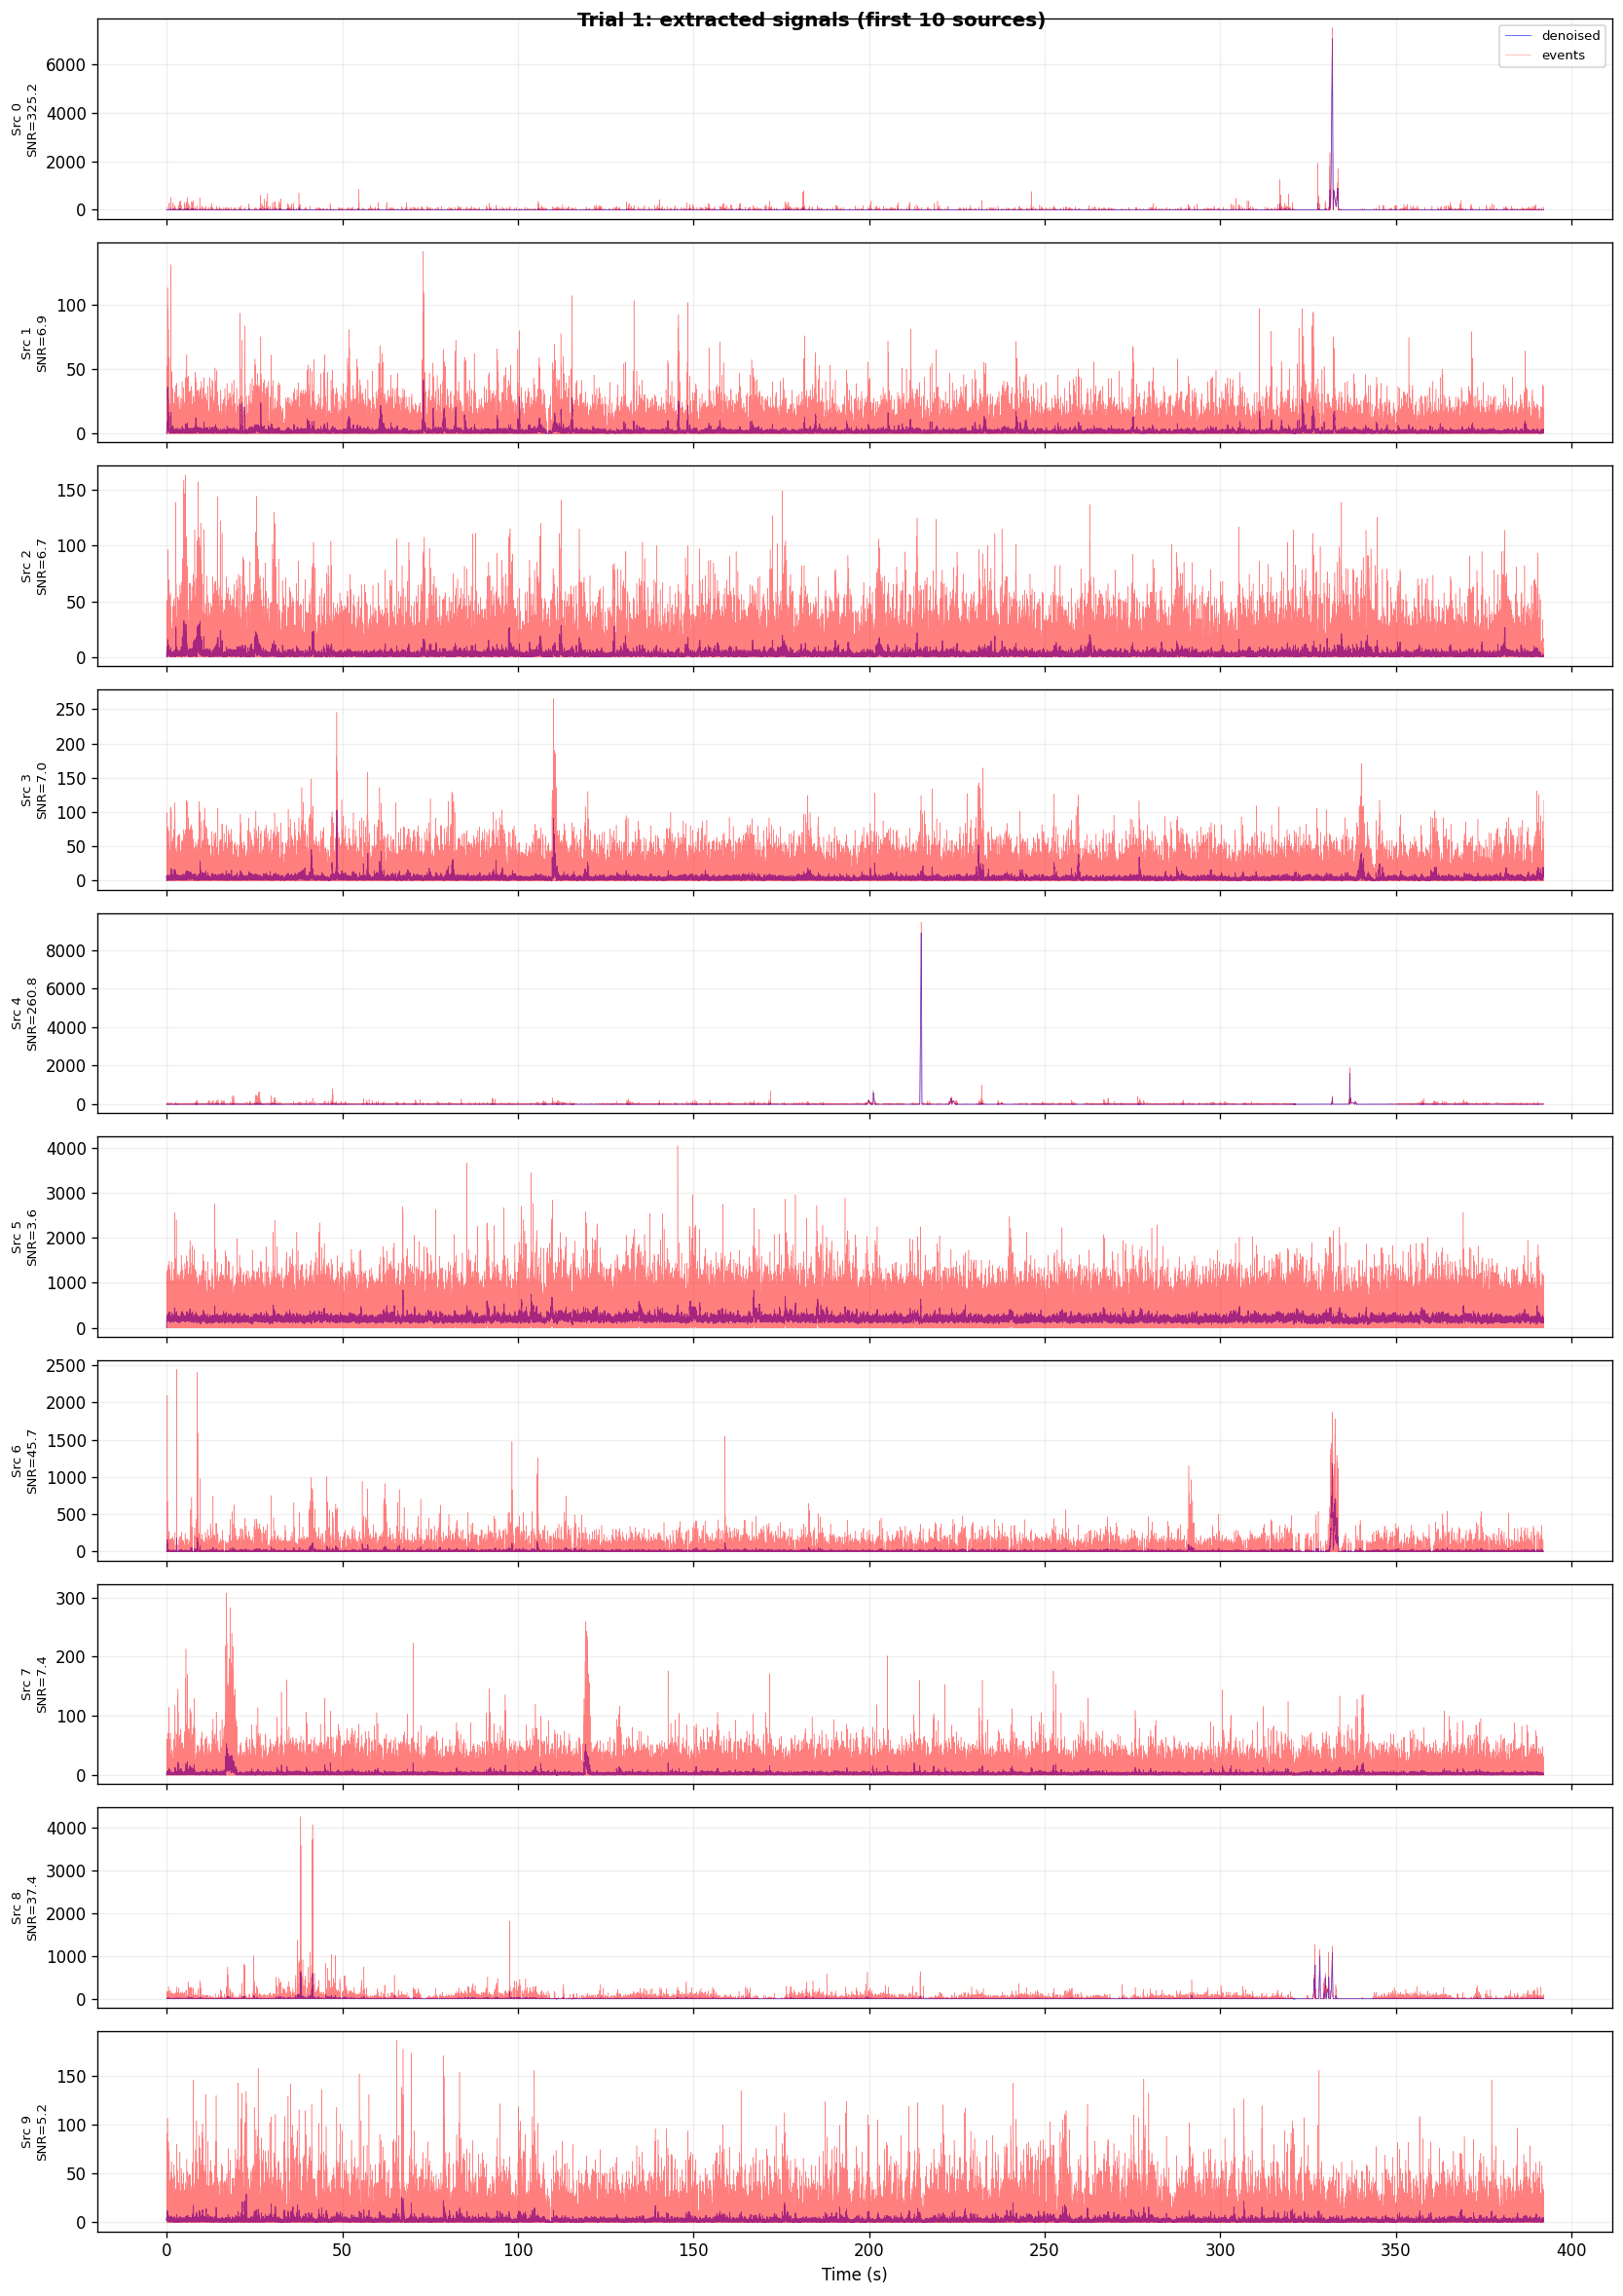

In [24]:
# Plot extracted signals for the first trial that succeeded
if extraction_results:
    trial_idx = list(extraction_results.keys())[0]
    ext = extraction_results[trial_idx]
    events = ext["events"]
    denoised = ext["denoised"]
    result = ext["result"]
    hz = ext["analyze_hz"]

    n_sources_plot = min(10, sources.n_sources)
    t = np.arange(events.shape[1]) / hz

    fig, axes = plt.subplots(n_sources_plot, 1, figsize=(14, 2 * n_sources_plot), sharex=True)
    if n_sources_plot == 1:
        axes = [axes]

    for i in range(n_sources_plot):
        ax = axes[i]
        ax.plot(t, denoised[i], "b-", lw=0.5, alpha=0.7, label="denoised")
        ax.plot(t, events[i], "r-", lw=0.3, alpha=0.5, label="events")
        snr_val = result.SNR[i] if not np.isnan(result.SNR[i]) else 0
        ax.set_ylabel(f"Src {i}\nSNR={snr_val:.1f}", fontsize=8)
        ax.grid(True, alpha=0.2)
        if i == 0:
            ax.legend(loc="upper right", fontsize=8)

    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(f"Trial {trial_idx}: extracted signals (first {n_sources_plot} sources)",
                 fontweight="bold")
    plt.tight_layout()
else:
    print("No extraction results to plot.")

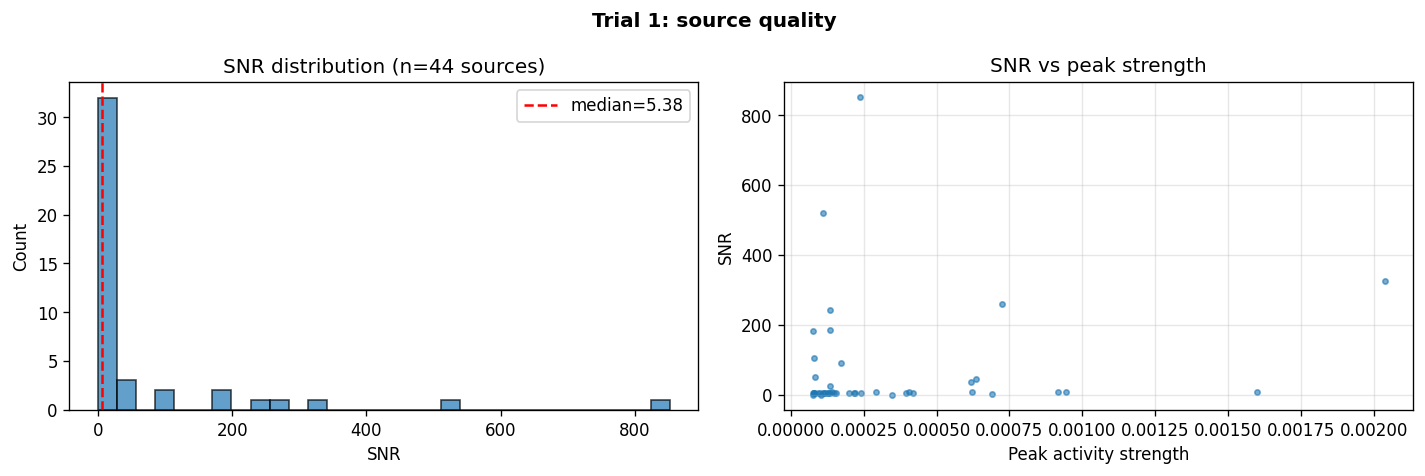

In [25]:
# SNR distribution across sources
if extraction_results:
    trial_idx = list(extraction_results.keys())[0]
    snr = extraction_results[trial_idx]["result"].SNR
    valid_snr = snr[~np.isnan(snr)]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(valid_snr, bins=30, edgecolor="k", alpha=0.7)
    axes[0].set_xlabel("SNR")
    axes[0].set_ylabel("Count")
    axes[0].set_title(f"SNR distribution (n={len(valid_snr)} sources)")
    axes[0].axvline(np.median(valid_snr), color="red", linestyle="--", label=f"median={np.median(valid_snr):.2f}")
    axes[0].legend()

    # SNR vs source strength
    axes[1].scatter(sources.values[:len(valid_snr)], valid_snr, s=10, alpha=0.6)
    axes[1].set_xlabel("Peak activity strength")
    axes[1].set_ylabel("SNR")
    axes[1].set_title("SNR vs peak strength")
    axes[1].grid(True, alpha=0.3)

    fig.suptitle(f"Trial {trial_idx}: source quality", fontweight="bold")
    plt.tight_layout()

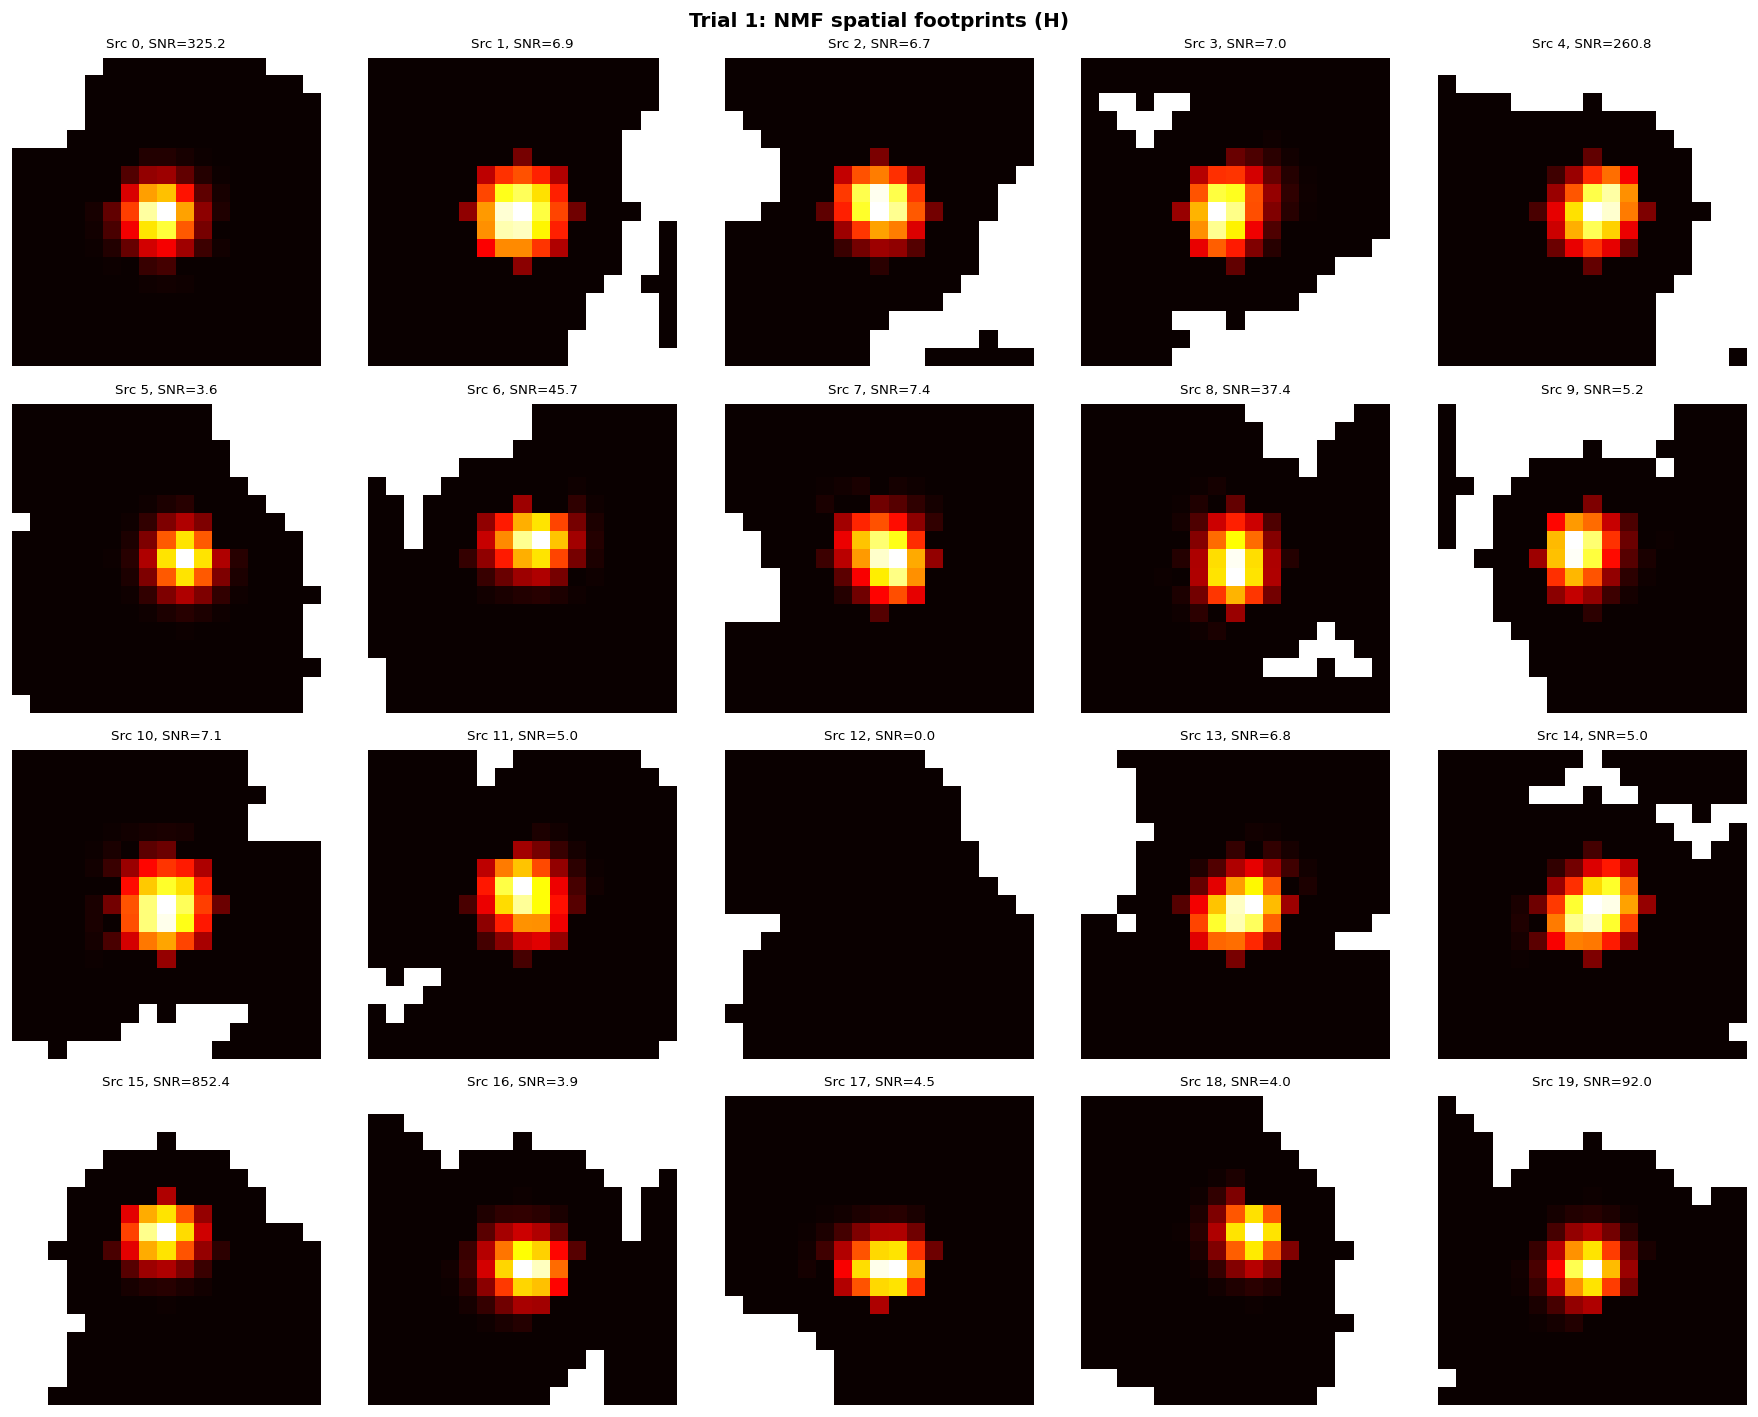

In [26]:
# Spatial footprints from NMF
if extraction_results:
    trial_idx = list(extraction_results.keys())[0]
    H = extraction_results[trial_idx]["result"].H  # (n_sel_pixels, n_sources)

    n_show = min(20, sources.n_sources)
    cols_plot = min(5, n_show)
    rows_plot = (n_show + cols_plot - 1) // cols_plot

    fig, axes = plt.subplots(rows_plot, cols_plot, figsize=(3 * cols_plot, 3 * rows_plot))
    axes_flat = np.array(axes).ravel()

    for i in range(n_show):
        r, c = int(round(sources.rows[i])), int(round(sources.cols[i]))
        pad = config.sel_radius + 2
        r0, r1 = max(0, r - pad), min(h, r + pad + 1)
        c0, c1 = max(0, c - pad), min(w, c + pad + 1)

        # Reconstruct 2D footprint from selected pixels
        h_img = np.full((h, w), np.nan)
        h_col = H[:, i]
        valid_h = ~np.isnan(h_col)
        h_img[sel_pix_union] = np.where(valid_h, h_col, 0)

        crop = h_img[r0:r1, c0:c1]
        vmax = np.nanmax(np.abs(crop)) if np.any(~np.isnan(crop)) else 1
        axes_flat[i].imshow(crop, cmap="hot", vmin=0, vmax=max(vmax, 1e-6))
        snr_val = extraction_results[trial_idx]["result"].SNR[i]
        axes_flat[i].set_title(f"Src {i}, SNR={snr_val:.1f}", fontsize=8)
        axes_flat[i].axis("off")

    for i in range(n_show, len(axes_flat)):
        axes_flat[i].axis("off")

    fig.suptitle(f"Trial {trial_idx}: NMF spatial footprints (H)", fontweight="bold")
    plt.tight_layout()

## 8. Compare with MATLAB results

If a MATLAB `SummaryLoCo-*.mat` file exists, compare source locations,
activity images, and extracted signals.

In [27]:
import scipy.io
import glob

# Helper to dereference MATLAB v7.3 HDF5 object references
def _deref(f, ds):
    """Dereference an HDF5 dataset containing a MATLAB object reference.
    
    MATLAB v7.3 stores struct fields as (1,1) object-ref datasets.
    The dereferenced data is already in MATLAB's (row, col) orientation.
    """
    if ds.dtype == object and ds.shape == (1, 1):
        target = f[ds[0, 0]]
        if isinstance(target, h5py.Dataset):
            return np.array(target)
        elif isinstance(target, h5py.Group):
            return target  # return group for struct fields
    return np.array(ds)

# Look for MATLAB summary file
summary_dir = data_dir / "ExperimentSummary"
matlab_files = sorted(glob.glob(str(summary_dir / "SummaryLoCo-*.mat"))) if summary_dir.exists() else []

if matlab_files:
    mat_path = matlab_files[-1]  # most recent
    print(f"Loading MATLAB summary: {Path(mat_path).name}")
    try:
        mat = scipy.io.loadmat(mat_path, squeeze_me=True)
        mat_keys = [k for k in mat.keys() if not k.startswith("__")]
        print(f"Keys: {mat_keys}")
    except NotImplementedError:
        # v7.3 .mat files need h5py
        import h5py
        mat = h5py.File(mat_path, "r")
        mat_keys = list(mat.keys())
        print(f"Keys (HDF5): {mat_keys}")
else:
    mat = None
    print(f"No MATLAB SummaryLoCo file found in {summary_dir}")
    print("Run MATLAB summarize_LoCo.m first to enable comparison.")

No MATLAB SummaryLoCo file found in C:\Users\user\Desktop\iGluSnFR test data\750098\2024-09-24\test_scan_00001_20240924_110500\ExperimentSummary
Run MATLAB summarize_LoCo.m first to enable comparison.


In [28]:
# Compare source locations if MATLAB results are available
if mat is not None:
    try:
        if isinstance(mat, dict):
            es = mat.get("exptSummary", mat)
        else:
            es = mat["exptSummary"]  # HDF5 group

        print("MATLAB exptSummary fields:")
        for field in sorted(es.keys()):
            ds = es[field]
            if isinstance(ds, h5py.Group):
                print(f"  {field}/ (struct with {len(ds)} fields)")
            elif isinstance(ds, h5py.Dataset):
                if ds.dtype == object:
                    # Dereference to show actual shape
                    arr = _deref(mat, ds)
                    if isinstance(arr, h5py.Group):
                        print(f"  {field} -> struct with keys: {list(arr.keys())}")
                    else:
                        print(f"  {field} -> shape={arr.shape}, dtype={arr.dtype}")
                else:
                    print(f"  {field}: shape={ds.shape}, dtype={ds.dtype}")

        # Compare peaks
        mat_peaks = _deref(mat, es["peaks"])
        if isinstance(mat_peaks, h5py.Group):
            mat_row = np.array(mat_peaks["row"]).ravel()
            mat_col = np.array(mat_peaks["col"]).ravel()
            # MATLAB 1-indexed -> Python 0-indexed
            mat_row = mat_row - 1
            mat_col = mat_col - 1
            print(f"\nMATLAB: {len(mat_row)} sources")
            print(f"Python: {sources.n_sources} sources")
            print(f"MATLAB rows[:10]: {mat_row[:10]}")
            print(f"Python rows[:10]: {sources.rows[:10]}")
            print(f"MATLAB cols[:10]: {mat_col[:10]}")
            print(f"Python cols[:10]: {sources.cols[:10]}")

    except Exception as e:
        print(f"Could not parse MATLAB summary: {e}")
        import traceback; traceback.print_exc()
else:
    print("Skipping MATLAB comparison (no file loaded).")

Skipping MATLAB comparison (no file loaded).


In [29]:
# Compare activity images side by side (if MATLAB data available)
if mat is not None:
    try:
        if isinstance(mat, dict):
            es = mat.get("exptSummary", mat)
            mat_act_aligned = es.get("perTrialActIMsAligned", None)
        else:
            es = mat["exptSummary"]
            mat_act_aligned = _deref(mat, es["perTrialActIMsAligned"])

        if mat_act_aligned is not None:
            # Replace inf with NaN (MATLAB activity images can have inf at edge pixels)
            mat_act_aligned = mat_act_aligned.astype(float)
            mat_act_aligned[~np.isfinite(mat_act_aligned)] = np.nan

            print(f"MATLAB activity image shape: {mat_act_aligned.shape}")
            if mat_act_aligned.ndim == 3:
                mat_avg_act = np.nanmean(mat_act_aligned, axis=-1)
            else:
                mat_avg_act = mat_act_aligned

            py_avg_act = np.mean(
                cross_result.aligned_activity[:, :, cross_result.valid_trials], axis=2
            )
            print(f"Python activity image shape: {py_avg_act.shape}")
            print(f"MATLAB finite range: [{np.nanmin(mat_avg_act):.2f}, {np.nanmax(mat_avg_act):.2f}]")
            print(f"Python value range:  [{np.nanmin(py_avg_act):.2f}, {np.nanmax(py_avg_act):.2f}]")

            fig, axes = plt.subplots(1, 3, figsize=(15, 5))

            # Per-image normalization
            vmax_m = np.nanpercentile(mat_avg_act, 99.5)
            vmax_p = np.nanpercentile(py_avg_act, 99.5)

            axes[0].imshow(mat_avg_act, cmap="hot", vmin=0, vmax=max(vmax_m, 1e-8))
            axes[0].set_title(f"MATLAB avg activity {mat_avg_act.shape}")
            axes[0].axis("off")

            axes[1].imshow(py_avg_act, cmap="hot", vmin=0, vmax=max(vmax_p, 1e-8))
            axes[1].set_title(f"Python avg activity {py_avg_act.shape}")
            axes[1].axis("off")

            # Difference — crop to common region if shapes differ
            min_r = min(mat_avg_act.shape[0], py_avg_act.shape[0])
            min_c = min(mat_avg_act.shape[1], py_avg_act.shape[1])
            diff = py_avg_act[:min_r, :min_c] - mat_avg_act[:min_r, :min_c]
            vd = np.nanpercentile(np.abs(diff[np.isfinite(diff)]), 99) if np.any(np.isfinite(diff)) else 1
            axes[2].imshow(diff, cmap="RdBu_r", vmin=-vd, vmax=vd)
            axes[2].set_title(f"Difference (cropped to {min_r}x{min_c})")
            axes[2].axis("off")

            fig.suptitle("MATLAB vs Python: averaged activity images", fontweight="bold")
            plt.tight_layout()
        else:
            print("Could not find aligned activity images in MATLAB output.")

    except Exception as e:
        print(f"Error comparing activity images: {e}")
        import traceback; traceback.print_exc()
else:
    print("Skipping activity image comparison (no MATLAB data).")

Skipping activity image comparison (no MATLAB data).


In [30]:
# Compare NMF spatial footprints: MATLAB vs Python
if mat is not None:
    import h5py

    try:
        es = mat["exptSummary"]

        # Navigate to E struct (cell array → object ref → group)
        E_ds = es["E"]
        E_struct = mat[E_ds[0, 0]] if E_ds.dtype == object else E_ds
        E_fields = list(E_struct.keys())

        # Load MATLAB selPix (2D union mask)
        mat_sel_pix = np.array(es["selPix"]).astype(bool)
        n_sel = int(np.sum(mat_sel_pix))
        mat_h, mat_w = mat_sel_pix.shape

        if "footprints" not in E_fields:
            print(f"MATLAB E struct does not contain NMF footprints.")
            print(f"  Available fields: {E_fields}")
            print(f"  MATLAB extraction may not have completed for this file.")
        else:
            mat_H = np.array(E_struct["footprints"])
            # Auto-orient to (n_sel_pixels, n_sources)
            if mat_H.shape[1] == n_sel and mat_H.shape[0] != n_sel:
                mat_H = mat_H.T
            n_mat_sources = mat_H.shape[1]

            # Get source locations from peaks
            mat_peaks_grp = _deref(mat, es["peaks"])
            if isinstance(mat_peaks_grp, h5py.Group):
                mat_src_row = np.array(mat_peaks_grp["row"]).ravel() - 1  # 0-indexed
                mat_src_col = np.array(mat_peaks_grp["col"]).ravel() - 1
            else:
                mat_src_row = mat_peaks_grp[:, 0] - 1
                mat_src_col = mat_peaks_grp[:, 1] - 1

            # If peaks count doesn't match footprints, extract centers from H maxima
            if len(mat_src_row) != n_mat_sources:
                print(f"Note: {len(mat_src_row)} peaks vs {n_mat_sources} footprint sources")
                print("  Extracting source centers from footprint maxima...")
                sel_coords = np.argwhere(mat_sel_pix)  # (n_sel, 2)
                mat_src_row = np.zeros(n_mat_sources, dtype=float)
                mat_src_col = np.zeros(n_mat_sources, dtype=float)
                for i in range(n_mat_sources):
                    peak_idx = np.nanargmax(mat_H[:, i])
                    mat_src_row[i] = sel_coords[peak_idx, 0]
                    mat_src_col[i] = sel_coords[peak_idx, 1]

            # Get SNR if available
            mat_snr = np.array(E_struct["SNR"]).ravel() if "SNR" in E_fields else None

            print(f"MATLAB: {n_mat_sources} sources, {n_sel} sel pixels, image {mat_h}x{mat_w}")
            if mat_snr is not None:
                valid_ms = mat_snr[~np.isnan(mat_snr)]
                print(f"  SNR range: [{np.min(valid_ms):.2f}, {np.max(valid_ms):.2f}]")

            # --- Plot MATLAB footprints ---
            n_show = min(20, n_mat_sources)
            cols_plot = min(5, n_show)
            rows_plot = (n_show + cols_plot - 1) // cols_plot
            fig, axes = plt.subplots(rows_plot, cols_plot,
                                     figsize=(3 * cols_plot, 3 * rows_plot))
            axes_flat = np.array(axes).ravel()

            for i in range(n_show):
                r, c = int(round(mat_src_row[i])), int(round(mat_src_col[i]))
                pad = config.sel_radius + 2
                r0, r1 = max(0, r - pad), min(mat_h, r + pad + 1)
                c0, c1 = max(0, c - pad), min(mat_w, c + pad + 1)

                h_img = np.full((mat_h, mat_w), np.nan)
                h_col = mat_H[:, i]
                valid_h = ~np.isnan(h_col)
                h_img[mat_sel_pix] = np.where(valid_h, h_col, 0)

                crop = h_img[r0:r1, c0:c1]
                vmax_val = np.nanmax(np.abs(crop)) if np.any(~np.isnan(crop)) else 1
                axes_flat[i].imshow(crop, cmap="hot", vmin=0, vmax=max(vmax_val, 1e-6))
                title = f"Src {i} ({r},{c})"
                if mat_snr is not None and i < len(mat_snr):
                    title += f"\nSNR={mat_snr[i]:.1f}"
                axes_flat[i].set_title(title, fontsize=8)
                axes_flat[i].axis("off")

            for i in range(n_show, len(axes_flat)):
                axes_flat[i].axis("off")

            fig.suptitle("MATLAB: NMF spatial footprints (H)", fontweight="bold")
            plt.tight_layout()

    except Exception as e:
        print(f"Error loading MATLAB footprints: {e}")
        import traceback; traceback.print_exc()
else:
    print("No MATLAB data loaded.")

No MATLAB data loaded.


## 9. Summary

In [31]:
print("=== Extraction Summary ===")
print(f"Data directory: {data_dir}")
print(f"Total trials: {n_trials}")
print(f"Valid trials (localization): {np.sum(keep_trials)}/{n_trials}")
print(f"Valid trials (cross-trial): {len(cross_result.valid_trials)}/{n_trials}")
print(f"Sources detected: {sources.n_sources}")
print(f"Trials extracted: {len(extraction_results)}/{len(cross_result.valid_trials)}")

if extraction_results:
    all_snr = []
    for trial_idx, ext in extraction_results.items():
        snr = ext["result"].SNR
        valid_snr = snr[~np.isnan(snr)]
        all_snr.extend(valid_snr.tolist())
    all_snr = np.array(all_snr)
    if len(all_snr) > 0:
        print(f"\nSNR across all extracted trials:")
        print(f"  Mean:   {np.mean(all_snr):.2f}")
        print(f"  Median: {np.median(all_snr):.2f}")
        print(f"  Range:  [{np.min(all_snr):.2f}, {np.max(all_snr):.2f}]")
        print(f"  Sources with SNR > 2: {np.sum(all_snr > 2)}/{len(all_snr)}")
    else:
        print(f"\nAll SNR values are NaN — SNR computation may need debugging")

print(f"\nMATLAB comparison: {'available' if mat is not None else 'not available'}")

=== Extraction Summary ===
Data directory: C:\Users\user\Desktop\iGluSnFR test data\750098\2024-09-24\test_scan_00001_20240924_110500
Total trials: 1
Valid trials (localization): 1/1
Valid trials (cross-trial): 1/1
Sources detected: 44
Trials extracted: 1/1

SNR across all extracted trials:
  Mean:   69.86
  Median: 5.38
  Range:  [0.00, 852.38]
  Sources with SNR > 2: 41/44

MATLAB comparison: not available
